In [1]:
# Install necessary libraries

!pip install xlrd

import numpy as np
import matplotlib.pyplot as plt
import PIL
import requests
import seaborn as sns
import pandas as pd
import scipy
import os
from glob import glob

In [2]:
# Data from the following websites: https://open.toronto.ca/dataset/licensed-dogs-and-cats-reports/, 
# https://open.toronto.ca/dataset/licensed-dogs-and-cats/
# Several sheets are available that list, per year, the number of dogs and cats registered in each 
# forward sortation area (zip code) in Toronto.
# These spreadsheets are available in multiple formats.  Want to consolidate them into a large dataframe.

In [3]:
os.getcwd()

'/Users/christineromano/DSI_Course/DSI_Visualization/visualization/02_activities/assignments/Files_for_Assignment_3'

In [4]:
# All of the registries from 2015 to 2022 were listed as .xls files and separated by year.
# These files were then placed into a subdirectory labelled "xls_files"  
# Checking on that subdirectory

xls_files = 'xls_files/by*.xls'
all_xls_files = glob(xls_files)
print(all_xls_files)

['xls_files/by-forward-sortation-area-fsa-2020.xls', 'xls_files/by-forward-sortation-area-fsa-2021.xls', 'xls_files/by-forward-sortation-area-fsa-2022.xls', 'xls_files/by-forward-sortation-area-fsa-2019.xls', 'xls_files/by-forward-sortation-area-fsa-2018.xls', 'xls_files/by-forward-sortation-area-fsa-2015.xls', 'xls_files/by-forward-sortation-area-fsa-2016.xls', 'xls_files/by-forward-sortation-area-fsa-2017.xls']


In [5]:
# All of the registries from 2018 to 2022 were listed as .xls files and separated by year.
# These files were then placed into a subdirectory labelled "xls_files"  
# Will consolidate these into one large file.

xls_files_pets_df = []
rows_to_drop = [0, 1, 2]

for file in all_xls_files:
    dataframe = pd.read_excel(file, header=None, index_col=None)
    dataframe = dataframe.dropna(axis = 1, how = 'all') # Dropping any empty columns
    dataframe = dataframe.drop(rows_to_drop, axis = 0) # Dropping the title rows.  Will re-add column titles later.

    # The next several steps are designed to add the year as a column

    filename = os.path.basename(file) # Extracting each filename
    name_parts = filename.split('-') # Splitting the filename by hyphen
    year_and_xls = name_parts[-1] # Selecting the final part of that hyphen, which contains "year.xls"
    year_parts = year_and_xls.split('.') # Splitting "year.xls" into "year" and ".xls"
    year = year_parts[-2] # Keeping the "year"
    dataframe['Year'] = year # Creating a "year" column for the dataframe

    # Now that all files have been standardized and a year has been added, 
    # append each one to a list of all the files that should be in the dataframe.

    xls_files_pets_df.append(dataframe) 

# Concatenate this list of files into a dataframe.

Toronto_pets_2015_to_2022 = pd.concat(xls_files_pets_df, ignore_index=True)
Toronto_pets_2015_to_2022.head()

,0,1,2,3,Year
0,M1B,186,440,626,2020
1,M1C,202,592,794,2020
2,M1E,331,640,971,2020
3,M1G,130,273,403,2020
4,M1H,88,225,313,2020


In [6]:
type(xls_files_pets_df)

list

In [7]:
xls_files_pets_df

[         0      1      2      3  Year
 3      M1B    186    440    626  2020
 4      M1C    202    592    794  2020
 5      M1E    331    640    971  2020
 6      M1G    130    273    403  2020
 7      M1H     88    225    313  2020
 ..     ...    ...    ...    ...   ...
 96     M9P    133    313    446  2020
 97     M9R    190    383    573  2020
 98     M9V    128    301    429  2020
 99     M9W    165    426    591  2020
 100  Total  17260  42937  60197  2020
 
 [98 rows x 5 columns],
          0      1      2      3  Year
 3      M1B    205    494    699  2021
 4      M1C    210    663    873  2021
 5      M1E    365    748   1113  2021
 6      M1G    142    296    438  2021
 7      M1H    101    235    336  2021
 ..     ...    ...    ...    ...   ...
 97     M9P    124    355    479  2021
 98     M9R    176    429    605  2021
 99     M9V    151    313    464  2021
 100    M9W    175    420    595  2021
 101  Total  18849  48664  67513  2021
 
 [99 rows x 5 columns],
          0 

In [8]:
# Add columns labels to dataframe 

Toronto_pets_2015_to_2022.columns = ['FSA', 'CAT', 'DOG', 'Total', 'Year']
Toronto_pets_2015_to_2022.head()

,FSA,CAT,DOG,Total,Year
0,M1B,186,440,626,2020
1,M1C,202,592,794,2020
2,M1E,331,640,971,2020
3,M1G,130,273,403,2020
4,M1H,88,225,313,2020


In [9]:
# Another discrepancy between the data from 2015 to 2022 and that from 2023 to 2025 is the number of FSAs available.
# For this analysis, I will only focus on FSAs that were examined in both 2015 and 2025.  
# Need to get this list of FSAs.  Will start with the 2015 to 2022 FSA list.

In [10]:
FSAs_by_year_2015_2022 = Toronto_pets_2015_to_2022.groupby("Year")["FSA"].unique()
FSAs_by_year_2015_2022.head()

Year
2015    [M1B, M1C, M1E, M1G, M1H, M1J, M1K, M1L, M1M, ...
2016    [M1B, M1C, M1E, M1G, M1H, M1J, M1K, M1L, M1M, ...
2017    [M1B, M1C, M1E, M1G, M1H, M1J, M1K, M1L, M1M, ...
2018    [M1B, M1C, M1E, M1G, M1H, M1J, M1K, M1L, M1M, ...
2019    [M1A, M1B, M1C, M1E, M1G, M1H, M1J, M1K, M1L, ...
Name: FSA, dtype: object

In [11]:
# Intersect across all years 2015 to 2022 to get FSAs that appear every year
common_fsas_2015_to_2022 = set(FSAs_by_year_2015_2022.iloc[0])
for fsas in FSAs_by_year_2015_2022.iloc[1:]:
    common_fsas_2015_to_2022 &= set(fsas)

In [12]:
common_fsas_2015_to_2022

{'M1B',
 'M1C',
 'M1E',
 'M1G',
 'M1H',
 'M1J',
 'M1K',
 'M1L',
 'M1M',
 'M1N',
 'M1P',
 'M1R',
 'M1S',
 'M1T',
 'M1V',
 'M1W',
 'M1X',
 'M2H',
 'M2J',
 'M2K',
 'M2L',
 'M2M',
 'M2N',
 'M2P',
 'M2R',
 'M3A',
 'M3B',
 'M3C',
 'M3H',
 'M3J',
 'M3K',
 'M3L',
 'M3M',
 'M3N',
 'M4A',
 'M4B',
 'M4C',
 'M4E',
 'M4G',
 'M4H',
 'M4J',
 'M4K',
 'M4L',
 'M4M',
 'M4N',
 'M4P',
 'M4R',
 'M4S',
 'M4T',
 'M4V',
 'M4W',
 'M4X',
 'M4Y',
 'M5A',
 'M5B',
 'M5C',
 'M5E',
 'M5G',
 'M5H',
 'M5J',
 'M5M',
 'M5N',
 'M5P',
 'M5R',
 'M5S',
 'M5T',
 'M5V',
 'M6A',
 'M6B',
 'M6C',
 'M6E',
 'M6G',
 'M6H',
 'M6J',
 'M6K',
 'M6L',
 'M6M',
 'M6N',
 'M6P',
 'M6R',
 'M6S',
 'M8V',
 'M8W',
 'M8X',
 'M8Y',
 'M8Z',
 'M9A',
 'M9B',
 'M9C',
 'M9L',
 'M9M',
 'M9N',
 'M9P',
 'M9R',
 'M9V',
 'M9W'}

In [13]:
len(common_fsas_2015_to_2022)

96

In [14]:
# Registries for years 2023 to 2025 are consolidated into a single .csv file where the data are presented 
# differently.  Need to try to get this file into the same format as the data for 2015 to 2022.
# Will start by reading the file into a dataframe from the csv.

Toronto_pets_2023_to_2025 = pd.read_csv('Licensed_Dogs_and_Cats.csv', index_col=False)
Toronto_pets_2023_to_2025 = Toronto_pets_2023_to_2025.dropna()
Toronto_pets_2023_to_2025.head()

,_id,Year,FSA,ANIMAL_TYPE,PRIMARY_BREED
0,1,2023,M1C,DOG,GOLDEN RETR
1,2,2024,M4T,DOG,OLDENG SHEEPDOG
2,3,2023,M8X,CAT,DOMESTIC SH
3,4,2024,M4J,CAT,DOMESTIC SH
4,5,2023,M3C,CAT,DOMESTIC SH


In [15]:
# Using this new dataframe, find all the FSAs that are unique to 2023 to 2025.

FSAs_2025 = Toronto_pets_2023_to_2025['FSA'].unique()
print(FSAs_2025)

['M1C' 'M4T' 'M8X' 'M4J' 'M3C' 'M9R' 'M8V' 'M8Y' 'M4C' 'M4B' 'M9L' 'M8Z'
 'M1P' 'M1E' 'M6M' 'M3K' 'M1H' 'M5M' 'M9A' 'M9P' 'M4P' 'M1G' 'M3J' 'M5V'
 'M3A' 'M9W' 'M9C' 'M4N' 'M9B' 'M2M' 'M5A' 'M1T' 'M6R' 'M1N' 'M6S' 'M1B'
 'M2H' 'M8W' 'M1V' 'M2N' 'M3B' 'M4M' 'M4G' 'M6J' 'M9M' 'M1W' 'M5P' 'M2J'
 'M4L' 'M6C' 'M1K' 'M4W' 'M6N' 'M4V' 'M4S' 'M5R' 'M1L' 'M6E' 'M6G' 'M6B'
 'M4X' 'M2R' 'M6L' 'M5N' 'M1R' 'M4A' 'M6P' 'M6K' 'M4E' 'M1S' 'M3M' 'M2K'
 'M6A' 'M4K' 'M2L' 'M4Y' 'M3H' 'M4R' 'M5J' 'M1J' 'M1X' 'M9V' 'M3L' 'M6H'
 'M9N' 'M1M' 'M5C' 'M2P' 'M5B' 'M4H' 'M5T' 'M5E' 'M3N' 'M5S' 'M5G' 'L6B'
 'L3T' 'M9T' 'N4L' 'L0L' 'M5H' 'L5E' 'L9S' 'K0H' 'K0L' 'K6K' 'L1E' 'L4J'
 'M5L' 'M7A' 'L7E' 'L0S' 'L6X' 'M6T' 'L7G' 'E2L' 'L4A' 'L1S' 'L0K' 'L3P'
 'L5A' 'N3C' 'L3X' 'L4B' 'L2P' 'L3Y' 'L0H' 'L1J' 'N6J' 'L4R' 'L1T' 'L4C'
 'L1N' 'N2J' 'L9V' 'L8N' 'L3Z' 'L4Y' 'L8M' 'L1H' 'K9V']


In [16]:
type(FSAs_2025)

numpy.ndarray

In [17]:
type(common_fsas_2015_to_2022)

set

In [18]:
# Need both FSA lists to be an array before I can intersect them, so will convert the set to an array
common_fsas_2015_to_2022_array = np.array(list(common_fsas_2015_to_2022)) 

In [19]:
# Find the intersection of the two lists

intersection_2015_2025 = np.intersect1d(common_fsas_2015_to_2022_array, FSAs_2025)
print(intersection_2015_2025)

['M1B' 'M1C' 'M1E' 'M1G' 'M1H' 'M1J' 'M1K' 'M1L' 'M1M' 'M1N' 'M1P' 'M1R'
 'M1S' 'M1T' 'M1V' 'M1W' 'M1X' 'M2H' 'M2J' 'M2K' 'M2L' 'M2M' 'M2N' 'M2P'
 'M2R' 'M3A' 'M3B' 'M3C' 'M3H' 'M3J' 'M3K' 'M3L' 'M3M' 'M3N' 'M4A' 'M4B'
 'M4C' 'M4E' 'M4G' 'M4H' 'M4J' 'M4K' 'M4L' 'M4M' 'M4N' 'M4P' 'M4R' 'M4S'
 'M4T' 'M4V' 'M4W' 'M4X' 'M4Y' 'M5A' 'M5B' 'M5C' 'M5E' 'M5G' 'M5H' 'M5J'
 'M5M' 'M5N' 'M5P' 'M5R' 'M5S' 'M5T' 'M5V' 'M6A' 'M6B' 'M6C' 'M6E' 'M6G'
 'M6H' 'M6J' 'M6K' 'M6L' 'M6M' 'M6N' 'M6P' 'M6R' 'M6S' 'M8V' 'M8W' 'M8X'
 'M8Y' 'M8Z' 'M9A' 'M9B' 'M9C' 'M9L' 'M9M' 'M9N' 'M9P' 'M9R' 'M9V' 'M9W']


In [20]:
# Although I love golden retrievers, my analysis today will not concern the particular breed of each pet.  
# Will drop that column for simplicity.
# Will also focus on grouping the data by year, FSA, and animal type, and tabulating the total number of cats or dogs 
# per FSA per year 

Toronto_pets_2023_to_2025_grouped_FSA = Toronto_pets_2023_to_2025.groupby(['Year', 'FSA', 'ANIMAL_TYPE']).size().reset_index()
Toronto_pets_2023_to_2025_grouped_FSA.head(20)

,Year,FSA,ANIMAL_TYPE,0
0,2023,E2L,DOG,1
1,2023,K0H,DOG,2
2,2023,K0L,DOG,1
3,2023,K6K,DOG,1
4,2023,L0K,CAT,2
5,2023,L0L,DOG,1
6,2023,L0S,DOG,1
7,2023,L1J,DOG,2
8,2023,L1S,DOG,1
9,2023,L2P,DOG,1


In [21]:
# Go through the 2015 to 2022 data and exclude any FSAs not found in "intersection_2015_2025"

FSA_filtered_2015_to_2022 = Toronto_pets_2015_to_2022[Toronto_pets_2015_to_2022['FSA'].isin(intersection_2015_2025)]
FSA_filtered_2015_to_2022.head()

,FSA,CAT,DOG,Total,Year
0,M1B,186,440,626,2020
1,M1C,202,592,794,2020
2,M1E,331,640,971,2020
3,M1G,130,273,403,2020
4,M1H,88,225,313,2020


In [22]:
# Go through the 2023 to 2025 data and exclude any FSAs not found in "intersection_2015_2025"

FSA_filtered_2023_to_2025 = Toronto_pets_2023_to_2025_grouped_FSA[Toronto_pets_2023_to_2025_grouped_FSA['FSA'].isin(intersection_2015_2025)]
FSA_filtered_2023_to_2025.head()

,Year,FSA,ANIMAL_TYPE,0
24,2023,M1B,CAT,208
25,2023,M1B,DOG,455
26,2023,M1C,CAT,186
27,2023,M1C,DOG,536
28,2023,M1E,CAT,355


In [23]:
# Need to reorganize the 2023 to 2025 data so that it lists cats and dogs separately.

df = FSA_filtered_2023_to_2025.rename(columns={0:'Count'}) # Renamed columns labelled '0' to 'Count'
unstacked_2023_to_2025 = df.set_index(['Year', 'FSA', 'ANIMAL_TYPE'])['Count'].unstack(fill_value=0)
unstacked_2023_to_2025.head()

ANIMAL_TYPE  CAT  DOG
Year FSA             
2023 M1B     208  455
     M1C     186  536
     M1E     355  685
     M1G     136  282
     M1H      81  201

In [24]:
unstacked_2023_to_2025.columns.name = None  # remove 'ANIMAL_TYPE' label
unstacked_2023_to_2025.head()

CAT  DOG
Year FSA          
2023 M1B  208  455
     M1C  186  536
     M1E  355  685
     M1G  136  282
     M1H   81  201

In [25]:
unstacked_2023_to_2025 = unstacked_2023_to_2025.reset_index()
unstacked_2023_to_2025.head()

,Year,FSA,CAT,DOG
0,2023,M1B,208,455
1,2023,M1C,186,536
2,2023,M1E,355,685
3,2023,M1G,136,282
4,2023,M1H,81,201


In [26]:
# Add a "totals" column to count total pet numbers, consistent with 2015 to 2022 data

unstacked_2023_to_2025['Total'] = unstacked_2023_to_2025['CAT'] + unstacked_2023_to_2025['DOG']
unstacked_2023_to_2025.head()


,Year,FSA,CAT,DOG,Total
0,2023,M1B,208,455,663
1,2023,M1C,186,536,722
2,2023,M1E,355,685,1040
3,2023,M1G,136,282,418
4,2023,M1H,81,201,282


In [27]:
# Reorder the columns in the 2023 to 2025 data so that they match the 2015 to 2022 data

new_column_order = ['FSA', 'CAT', 'DOG', 'Total', 'Year']

Toronto_2023_to_2025_reordered = unstacked_2023_to_2025[new_column_order]
Toronto_2023_to_2025_reordered.head()

,FSA,CAT,DOG,Total,Year
0,M1B,208,455,663,2023
1,M1C,186,536,722,2023
2,M1E,355,685,1040,2023
3,M1G,136,282,418,2023
4,M1H,81,201,282,2023


In [28]:
# Combine the 2015 to 2022 data with the 2023 to 2025 data

Toronto_pets_2015_to_2025 = pd.concat([Toronto_pets_2015_to_2022, Toronto_2023_to_2025_reordered], ignore_index=True)
Toronto_pets_2015_to_2025.head()

,FSA,CAT,DOG,Total,Year
0,M1B,186,440,626,2020
1,M1C,202,592,794,2020
2,M1E,331,640,971,2020
3,M1G,130,273,403,2020
4,M1H,88,225,313,2020


In [29]:
# Sort the data by year

Toronto_pets_2015_to_2025['Year'] = pd.to_numeric(Toronto_pets_2015_to_2025['Year'], errors='coerce') # make sure all data is numeric
Pets_per_year_Toronto = Toronto_pets_2015_to_2025.sort_values(by = 'Year', ascending= True).reset_index(drop=True)
Pets_per_year_Toronto.head()

,FSA,CAT,DOG,Total,Year
0,M4K,441,930,1371,2015
1,M6B,163,469,632,2015
2,M6A,144,219,363,2015
3,M5X,0,2,2,2015
4,M5W,6,1,7,2015


In [30]:
# True only when all three values in the row match
FSAs_by_year = Pets_per_year_Toronto.groupby("Year")["FSA"].unique()
FSAs_by_year.head()
#FSA_list_final = Pets_per_year_Toronto['FSA'].groupby['Year'].nunique(axis=1).eq(1)

Year
2015    [M4K, M6B, M6A, M5X, M5W, M5V, M5T, M5S, M5R, ...
2016    [M3A, M3B, M3C, M3H, M3J, M3K, M3L, M3M, M3N, ...
2017    [M5T, M6H, M6G, M6E, M6C, M6B, M6A, M5W, M5V, ...
2018    [M3N, M3M, M3L, M3C, M3J, M3H, M3B, M3K, M4A, ...
2019    [M2P, M2R, M3A, M3B, M3C, M3H, M3J, M3K, M3L, ...
Name: FSA, dtype: object

In [31]:
# Intersect across all years to get FSAs that appear every year
common_fsas = set(FSAs_by_year.iloc[0])
for fsas in FSAs_by_year.iloc[1:]:
    common_fsas &= set(fsas)

In [32]:
len(common_fsas)

96

In [33]:
# Export this final dataframe to a .csv file

Pets_per_year_Toronto.to_csv('Pets_per_year_Toronto.csv')


In [34]:
# Now that data is consolidated, let's look at dog and cat counts per year
# First need to make sure that all entries are numeric

Numeric_columns = ['CAT', 'DOG', 'Total', 'Year']
Pets_per_year_Toronto[Numeric_columns] = Pets_per_year_Toronto[Numeric_columns].apply(pd.to_numeric, errors = 'coerce')

Cats_each_year_Toronto = Pets_per_year_Toronto.groupby('Year')['CAT'].sum().reset_index()
Cats_each_year_Toronto.head(11)

,Year,CAT
0,2015,25018
1,2016,24701
2,2017,48990
3,2018,45858
4,2019,40230
5,2020,34520
6,2021,37698
7,2022,34222
8,2023,17465
9,2024,17871


In [35]:
Dogs_each_year_Toronto = Pets_per_year_Toronto.groupby('Year')['DOG'].sum().reset_index()
Dogs_each_year_Toronto.head(11)

,Year,DOG
0,2015,54782
1,2016,55121
2,2017,112918
3,2018,109064
4,2019,99276
5,2020,85874
6,2021,97328
7,2022,90780
8,2023,44346
9,2024,44216


In [36]:
pet_columns = ['DOG', 'CAT']
Dogs_Cats_each_year_Toronto = Pets_per_year_Toronto.groupby('Year')[pet_columns].sum().reset_index()
Dogs_Cats_each_year_Toronto.head(11)

,Year,DOG,CAT
0,2015,54782,25018
1,2016,55121,24701
2,2017,112918,48990
3,2018,109064,45858
4,2019,99276,40230
5,2020,85874,34520
6,2021,97328,37698
7,2022,90780,34222
8,2023,44346,17465
9,2024,44216,17871


In [37]:
# Export this data to a CSV

Dogs_Cats_each_year_Toronto.to_csv('Dogs_Cats_each_year_Toronto.csv')

In [38]:
# Want to tabulate pets per person in each FSA.  
# Will use 2021 census data per FSA, found here: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=9810001901
# Import Census Data into dataframe 

Ontario_census_2021 = pd.read_csv('9810001901-eng.csv', skiprows = 7)
Ontario_census_2021.head()

,Population and dwelling counts (3),"Population, 2021","Total private dwellings, 2021","Private dwellings occupied by usual residents, 2021"
0,Geographic name,NaN,NaN,NaN
1,Canada 2,"36,991,981","16,284,235","14,978,941"
2,A0A,"44,930","26,102","19,752"
3,A0B,"19,287","13,265","9,100"
4,A0C,"11,972","8,069","5,610"


In [39]:
Ontario_census_2021.columns

Index(['Population and dwelling counts (3)', 'Population, 2021',
       'Total private dwellings, 2021',
       'Private dwellings occupied by usual residents, 2021'],
      dtype='object')

In [40]:
Ontario_census_2021_Toronto = Ontario_census_2021[Ontario_census_2021['Population and dwelling counts (3)'].isin(intersection_2015_2025)]
Ontario_census_2021_Toronto.head()

,Population and dwelling counts (3),"Population, 2021","Total private dwellings, 2021","Private dwellings occupied by usual residents, 2021"
895,M1B,"65,555","21,561","20,563"
896,M1C,"35,642","11,724","11,396"
897,M1E,"48,033","18,085","17,320"
898,M1G,"30,894","10,791","10,313"
899,M1H,"23,964","9,021","8,632"


In [41]:
Toronto_area_population = Ontario_census_2021_Toronto[['Population and dwelling counts (3)', 'Population, 2021']]
Toronto_area_population.head()

,Population and dwelling counts (3),"Population, 2021"
895,M1B,"65,555"
896,M1C,"35,642"
897,M1E,"48,033"
898,M1G,"30,894"
899,M1H,"23,964"


In [42]:
Toronto_area_population_renamed = Toronto_area_population.rename(columns = {'Population and dwelling counts (3)': 'FSA', 'Population, 2021':'Population'}).reset_index(drop = True)
Toronto_area_population_renamed.head()

,FSA,Population
0,M1B,"65,555"
1,M1C,"35,642"
2,M1E,"48,033"
3,M1G,"30,894"
4,M1H,"23,964"


In [43]:
# Gather 2021 data from Pet Registration Spreadsheet 

Pets_in_2021 = Pets_per_year_Toronto[Pets_per_year_Toronto['Year'] == 2021]
Pets_in_2021.head()

,FSA,CAT,DOG,Total,Year
593,M3K,51,106,157,2021
594,M4G,152,710,862,2021
595,M3L,48,156,204,2021
596,M3M,127,239,366,2021
597,M3N,147,212,359,2021


In [44]:
# Merge Census data on human population with registration data on pet populations per FSA

merged_2021 = Pets_in_2021.merge(Toronto_area_population_renamed, on = 'FSA', how = 'inner')
merged_2021.head()

,FSA,CAT,DOG,Total,Year,Population
0,M3K,51,106,157,2021,"7,865"
1,M4G,152,710,862,2021,"19,598"
2,M3L,48,156,204,2021,"19,263"
3,M3M,127,239,366,2021,"24,906"
4,M3N,147,212,359,2021,"40,846"


In [45]:
# Had to export to csv and reimport to get calculations to work.  I tried to avoid this step...
merged_2021.to_csv('merged_2021.csv')

In [46]:
Pets_and_humans_2021 = pd.read_csv('merged_2021.csv', index_col=0)
Pets_and_humans_2021.head()

,FSA,CAT,DOG,Total,Year,Population
0,M3K,51,106,157,2021,"7,865"
1,M4G,152,710,862,2021,"19,598"
2,M3L,48,156,204,2021,"19,263"
3,M3M,127,239,366,2021,"24,906"
4,M3N,147,212,359,2021,"40,846"


In [47]:
Pets_and_humans_2021.dtypes

FSA           object
CAT            int64
DOG            int64
Total          int64
Year           int64
Population    object
dtype: object

In [48]:
# Noted above that "Population" is an object and we need it to be a float.  Will convert.
# First convert 'Population' to a string.
# Remove comma from 'Population' by replacing it with nothing
# 
Pets_and_humans_2021['Population'] = Pets_and_humans_2021['Population'].astype(str)
Pets_and_humans_2021['Population'] = Pets_and_humans_2021['Population'].str.replace(',', '')
Pets_and_humans_2021.head()

,FSA,CAT,DOG,Total,Year,Population
0,M3K,51,106,157,2021,7865
1,M4G,152,710,862,2021,19598
2,M3L,48,156,204,2021,19263
3,M3M,127,239,366,2021,24906
4,M3N,147,212,359,2021,40846


In [49]:
# Convert the string 'Population' to a float.

Pets_and_humans_2021['Population'] = Pets_and_humans_2021['Population'].astype(float)
Pets_and_humans_2021.head()

,FSA,CAT,DOG,Total,Year,Population
0,M3K,51,106,157,2021,7865.0
1,M4G,152,710,862,2021,19598.0
2,M3L,48,156,204,2021,19263.0
3,M3M,127,239,366,2021,24906.0
4,M3N,147,212,359,2021,40846.0


In [50]:
# Can finally calculate dogs and cats per capita in each FSA in 2021

Pets_and_humans_2021['Dogs_Per_Person'] = Pets_and_humans_2021['DOG']/Pets_and_humans_2021['Population']
Pets_and_humans_2021['Cats_Per_Person'] = Pets_and_humans_2021['CAT']/Pets_and_humans_2021['Population']
Pets_and_humans_2021.head()

,FSA,CAT,DOG,Total,Year,Population,Dogs_Per_Person,Cats_Per_Person
0,M3K,51,106,157,2021,7865.0,0.013477,0.006484
1,M4G,152,710,862,2021,19598.0,0.036228,0.007756
2,M3L,48,156,204,2021,19263.0,0.008098,0.002492
3,M3M,127,239,366,2021,24906.0,0.009596,0.005099
4,M3N,147,212,359,2021,40846.0,0.005190,0.003599


In [ ]:
# Export to CSV.  Will use this data to prepare a graph in Excel.

Pets_and_humans_2021.to_csv('Pets_and_humans_2021.csv')

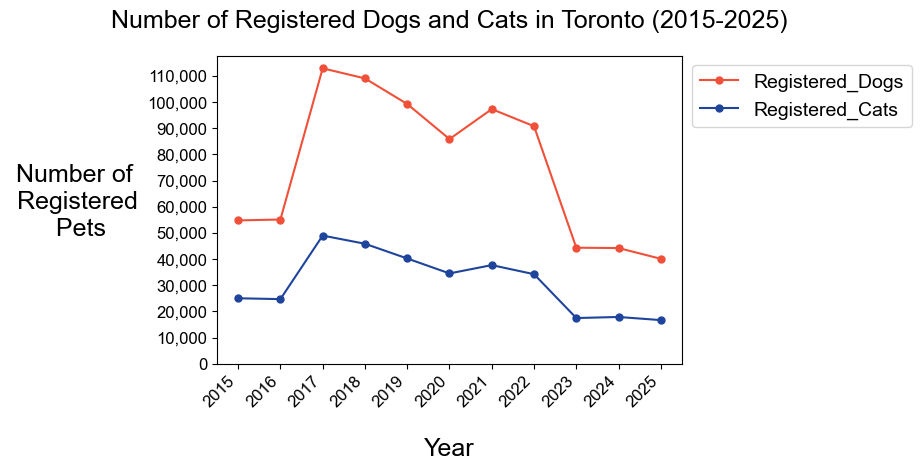

In [118]:
# Meanwhile, use the plot of Dogs_Cats_each_year_Toronto to make a figure in matplotlib 
# showing pet registration in Toronto from 2015 to 2025

font1 = {'family' : 'Arial', 'color': 'Black'} # Need to use a font dictionary to change title of graph.

x = Dogs_Cats_each_year_Toronto['Year']
y1 = Dogs_Cats_each_year_Toronto['DOG']
y2 = Dogs_Cats_each_year_Toronto['CAT']

fig, ax = plt.subplots(figsize = (6, 4)) 
ax.plot(x, y1, label = 'Registered_Dogs', color = '#F05039', marker = '.', markersize = 10)
ax.plot(x, y2, label = 'Registered_Cats', color = '#1F449C', marker = '.', markersize = 10)

# Color choices taken from: https://www.datylon.com/blog/data-visualization-for-colorblind-readers



ax.legend(loc = 'upper left', bbox_to_anchor = (1, 1), prop = {'family': 'Arial', 'size' : 14})
plt.xlabel('Year', fontsize = 18, fontdict = font1, color = 'Black', labelpad=20)
plt.ylabel('Number of \n Registered \n Pets', fontsize = 18, fontdict = font1, 
           color = 'Black', 
           labelpad=10, rotation = 0)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
plt.xticks(rotation = 45, ha= 'right', fontsize = 12, fontname = 'Arial')
plt.yticks(ha= 'right', fontsize = 12, fontname = 'Arial')
ax.yaxis.set_major_locator(plt.MultipleLocator(10000))

# Code from ChatGPT to force y axis to start at 0.  Not strictly necessary, but 
# I have a pet peeve about plots that don't start with the y - axis at 0.

ax.set_ylim(bottom=0)

ax.yaxis.set_label_coords(-0.3, 0.4)

ax.set_title(
    "Number of Registered Dogs and Cats in Toronto (2015-2025)", 
    fontsize=18, 
    fontname='Arial', 
    color='black', 
    pad=20  # distance from the plot
)

# Code recommended by ChatGPT to add commas to y-axis markers

from matplotlib.ticker import StrMethodFormatter
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

fig.savefig('Dogs_Cats_Toronto_2015_to_2025.png', dpi=600, bbox_inches='tight')

plt.show()
